# Henry Salgado
## Last Edit: March 2025

Purpose: Determine amount of missing data per construct per each of the three samples.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# This sample contains all 3 samples
combined_samples =  pd.read_csv("/Users/henrysalgado/Desktop/Coache Data Analysis/Samples/combined_samples.csv")

First, we will replace all non-response values as missing. 

In [17]:
non_response_codes = [96, 97, 98, 99]
combined_samples.replace(non_response_codes, np.nan, inplace=True)


Then, let's group items into constructs. For now, I will classify items into constructs based on previous studies or COACHE benchmark order (eg. q45a, q45b, etc). We will visualize percentage of missing data per sample. 

In [18]:
constructs = {
    "Chair Support": ["q185h", "q185i", "q185j", "q185k", "q185l"],
    "Institutional Resources": ["q90a", "q90c", "q90d", "q90e", "q90f", "q90h"],
    "Recognition": ["q215a", "q215b", "q215c", "q215e", "q215d", "q215i", "q215l"],
    "Worklife Balance": ["q55a", "q55b", "q200a", "q200b", "q200c", "q200d"],
    "Compensation and Benefits": [
        "q90g", "q95a", "q95b", "q95c", "q95d", "q95e", "q95f", "q95h", "q95i", "q95j", "q95k", "q95l", "q95m", "q95n"
    ],
    "Relatedness": ["q210c", "q212a", "q105a", "q105e", "q205c"],
    "Competence": ["q45a", "q45c", "q45d", "q45e"],
    "Mentoring": ["q120a", "q120b", "q120c"],
    "Promotion NTT": ['q460a', 'q460b', 'q460c', 'q460d', 'q460e'],
    "Autonomy": ["q188b", "q188a", "q186d"],
    "Service Satisfaction": ["q60a", "q60b", "q60c", "q60d", "q60e", "q60f", "q60g", "q60h", "q60i"],
    "Teaching": ["q70a", "q70b", "q70c", "q70d", "q70e", "q70f", "q70h", "q70k", "q70l", "q70m", "q70n"],
    "Global Satisfaction": ["q245d", "q250a", "q250b"]
}



In [ ]:
import pandas as pd

missing_summary = []

for construct_name, items in constructs.items():
   
    grouped = combined_samples.groupby("sample")[items].apply(lambda x: x.isna().mean(axis=1).mean() * 100)
    for sample, percent_missing in grouped.items():
        missing_summary.append({
            "sample": sample,
            "construct": construct_name,
            "percent_missing": percent_missing
        })

missing_df = pd.DataFrame(missing_summary)


Insight 1: We can see that Compensation and Benefits has the highest percent of missing data. Possible constructs with less than 20% of missing data per construct are : Chair Support, Ins Resources, Worklife Balance, Relatedness, Competence (time), mentoring, promotion (except sample 1), teaching, and global satisfaction

Constructs to be cautios of: Comp and Benefits, Autonomy, Service

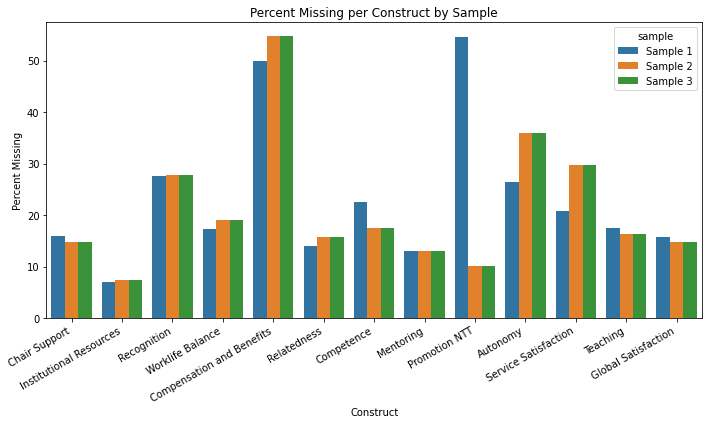

In [ ]:

plt.figure(figsize=(10, 6))
sns.barplot(data=missing_df, x="construct", y="percent_missing", hue="sample")

plt.title("Percent Missing per Construct by Sample")
plt.ylabel("Percent Missing")
plt.xlabel("Construct")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Current Version of Construct based on EFA 

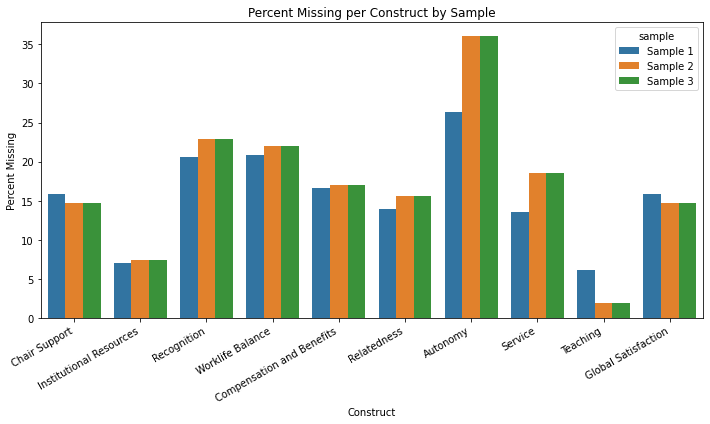

In [ ]:
constructs = {
    "Chair Support": ["q185h", "q185i", "q185j", "q185k", "q185l"],
    "Institutional Resources": ["q90a", "q90c", "q90d", "q90e", "q90f", "q90h"],
    "Recognition": ["q215a", "q215b", "q215l"],
    "Worklife Balance": ["q200a", "q200b", "q200c", "q200d"],
    "Compensation and Benefits": [ "q95a", "q95b", "q95c"],
    "Relatedness": ["q210c", "q212a", "q105a", "q105e", "q205c"],
    "Autonomy": ["q188b", "q188a", "q186d"],
    "Service": ["q45c", "q60a", "q60c", "q60d", "q60e"],
    "Teaching": ["q45a","q70a", "q70b", "q70d","q70c", "q70e"],
    "Global Satisfaction": ["q245d", "q250a", "q250b"]
}

import pandas as pd

missing_summary = []

for construct_name, items in constructs.items():
   
    grouped = combined_samples.groupby("sample")[items].apply(lambda x: x.isna().mean(axis=1).mean() * 100)
    for sample, percent_missing in grouped.items():
        missing_summary.append({
            "sample": sample,
            "construct": construct_name,
            "percent_missing": percent_missing
        })

missing_df = pd.DataFrame(missing_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=missing_df, x="construct", y="percent_missing", hue="sample")

plt.title("Percent Missing per Construct by Sample")
plt.ylabel("Percent Missing")
plt.xlabel("Construct")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



# Item Dropper

In [24]:
def suggest_items_to_drop_by_sample(data, constructs, non_response_codes=None, threshold=20, sample_col='sample'):
   
  
    data = data.copy()
    if non_response_codes is not None:
        data.replace(non_response_codes, np.nan, inplace=True)

    drop_suggestions = {}

    for sample_name, group_df in data.groupby(sample_col):
        sample_suggestions = {}
        for construct, items in constructs.items():
            # Only use columns that exist in this sample
            available_items = [col for col in items if col in group_df.columns]
            if not available_items:
                continue

            missing_per_item = group_df[available_items].isna().mean() * 100
            items_to_drop = missing_per_item[missing_per_item > threshold].index.tolist()
            if items_to_drop:
                sample_suggestions[construct] = items_to_drop

        if sample_suggestions:
            drop_suggestions[sample_name] = sample_suggestions

    return drop_suggestions


In [25]:
to_drop_by_sample = suggest_items_to_drop_by_sample(
    data=combined_samples,
    constructs=constructs,
    non_response_codes=non_response_codes,
    threshold=20
)

import pprint
pprint.pprint(to_drop_by_sample)

{'Sample 1': {'Autonomy': ['q188b', 'q188a', 'q186d'],
              'Compensation and Benefits': ['q95b'],
              'Recognition': ['q215b'],
              'Worklife Balance': ['q200b', 'q200c']},
 'Sample 2': {'Autonomy': ['q188b', 'q188a', 'q186d'],
              'Compensation and Benefits': ['q95b'],
              'Recognition': ['q215b'],
              'Relatedness': ['q105e'],
              'Service': ['q60e'],
              'Worklife Balance': ['q200b', 'q200c']},
 'Sample 3': {'Autonomy': ['q188b', 'q188a', 'q186d'],
              'Compensation and Benefits': ['q95b'],
              'Recognition': ['q215b'],
              'Relatedness': ['q105e'],
              'Service': ['q60e'],
              'Worklife Balance': ['q200b', 'q200c']}}
